# Q1: Affordability Gap Analysis
**CarIQ Capstone — Phase 4 EDA**

## Business Question
What percentage of customers who took a loan were matched to a car
within their computed EMI budget, and which price segments have
the highest unaffordability rate?

## Methodology
- Affordability threshold: EMI ≤ 40% of monthly income (standard RBI lending guideline)
- Income normalized to USD for cross-country comparability
- EMI converted from INR to USD using FEDAI locked rate (₹93.5 = $1)

## Data Source
`analytics/data/master.csv` — denormalized join of all 4 operational tables

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 40)

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
master = pd.read_csv('../data/master.csv')
print(f"Master DataFrame: {master.shape[0]} rows × {master.shape[1]} columns")
print(f"\nColumns:\n{list(master.columns)}")

Master DataFrame: 94 rows × 40 columns

Columns:
['transaction_id', 'lead_id', 'customer_id', 'vehicle_id', 'transaction_date', 'final_price_inr', 'loan_amount', 'loan_tenure_months', 'interest_rate', 'emi_amount', 'payment_mode', 'created_at', 'tx_month', 'tx_year', 'tx_quarter', 'is_loan', 'full_name', 'city', 'state', 'country', 'currency_code_customer', 'annual_income_local', 'annual_income_usd', 'monthly_income_local', 'monthly_income_usd', 'credit_score', 'employment_type', 'income_segment', 'credit_band', 'make', 'model', 'segment', 'fuel_type', 'price_local', 'currency_code_vehicle', 'price_usd_equivalent', 'price_segment', 'emi_amount_usd', 'affordability_ratio', 'is_affordable']


In [3]:
# Isolate loan transactions only — affordability only applies to loans
loans = master[master['payment_mode'] == 'Loan'].copy()
print(f"Total transactions : {len(master)}")
print(f"Loan transactions  : {len(loans)}")
print(f"Non-loan (Cash/Lease): {len(master) - len(loans)}\n")

# Affordability summary
affordable     = loans['is_affordable'].sum()
not_affordable = loans['is_affordable'].eq(0).sum()
null_ratio     = loans['affordability_ratio'].isna().sum()

print(f"── Affordability Breakdown (Loan transactions only) ──")
print(f"  Affordable   (EMI ≤ 40% income): {affordable}")
print(f"  Unaffordable (EMI > 40% income): {not_affordable}")
print(f"  Null ratio   (no EMI data)      : {null_ratio}\n")

print(f"── EMI Statistics (USD) ──")
print(loans['emi_amount_usd'].describe().round(2))

print(f"\n── Affordability Ratio Statistics ──")
print(loans['affordability_ratio'].describe().round(4))

Total transactions : 94
Loan transactions  : 60
Non-loan (Cash/Lease): 34

── Affordability Breakdown (Loan transactions only) ──
  Affordable   (EMI ≤ 40% income): 33
  Unaffordable (EMI > 40% income): 27
  Null ratio   (no EMI data)      : 0

── EMI Statistics (USD) ──
count       60.00
mean     5,907.46
std     12,519.32
min         66.08
25%        230.01
50%        581.76
75%      4,327.06
max     58,754.60
Name: emi_amount_usd, dtype: float64

── Affordability Ratio Statistics ──
count   60.00
mean     4.71
std      9.67
min      0.01
25%      0.10
50%      0.30
75%      2.99
max     44.09
Name: affordability_ratio, dtype: float64


In [4]:
# Group by price segment — which segments are least affordable?
segment_aff = loans.groupby('price_segment', observed=True).agg(
    total_loans      = ('is_affordable', 'count'),
    affordable_count = ('is_affordable', 'sum'),
    avg_ratio        = ('affordability_ratio', 'mean'),
    avg_emi_usd      = ('emi_amount_usd', 'mean'),
    avg_income_usd   = ('monthly_income_usd', 'mean')
).reset_index()

segment_aff['unaffordable_count'] = (
    segment_aff['total_loans'] - segment_aff['affordable_count']
)
segment_aff['affordable_pct'] = (
    segment_aff['affordable_count'] / segment_aff['total_loans'] * 100
).round(1)
segment_aff['avg_ratio_pct'] = (
    segment_aff['avg_ratio'] * 100
).round(1)

print(segment_aff[[
    'price_segment','total_loans','affordable_count',
    'unaffordable_count','affordable_pct','avg_ratio_pct'
]].to_string(index=False))

      price_segment  total_loans  affordable_count  unaffordable_count  affordable_pct  avg_ratio_pct
      Budget (<$5K)            4                 4                   0          100.00           6.90
   Economy ($5–15K)           15                13                   2           86.70          16.70
      Mid ($15–30K)           14                12                   2           85.70          19.30
 Premium ($60–150K)            8                 3                   5           37.50         192.30
     Ultra ($150K+)           16                 0                  16            0.00       1,613.80
Upper-Mid ($30–60K)            3                 1                   2           33.30         117.20


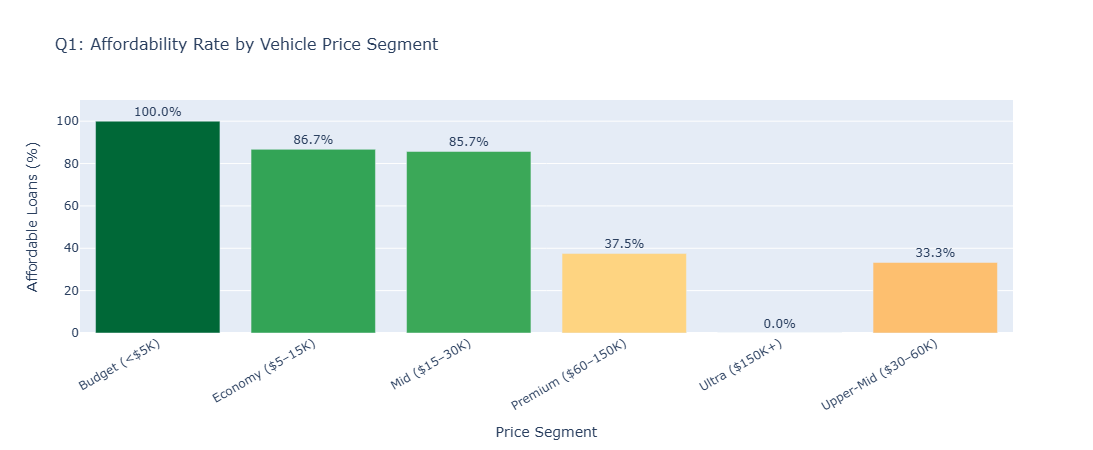

In [5]:
fig1 = px.bar(
    segment_aff,
    x='price_segment',
    y='affordable_pct',
    color='affordable_pct',
    color_continuous_scale='RdYlGn',
    range_color=[0, 100],
    title='Q1: Affordability Rate by Vehicle Price Segment',
    labels={
        'price_segment': 'Price Segment',
        'affordable_pct': 'Affordable Loans (%)'
    },
    text='affordable_pct'
)

fig1.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig1.update_layout(
    xaxis_tickangle=-30,
    coloraxis_showscale=False,
    yaxis=dict(range=[0, 110], title='Affordable Loans (%)'),
    title_font_size=16,
    height=450
)

fig1.show()

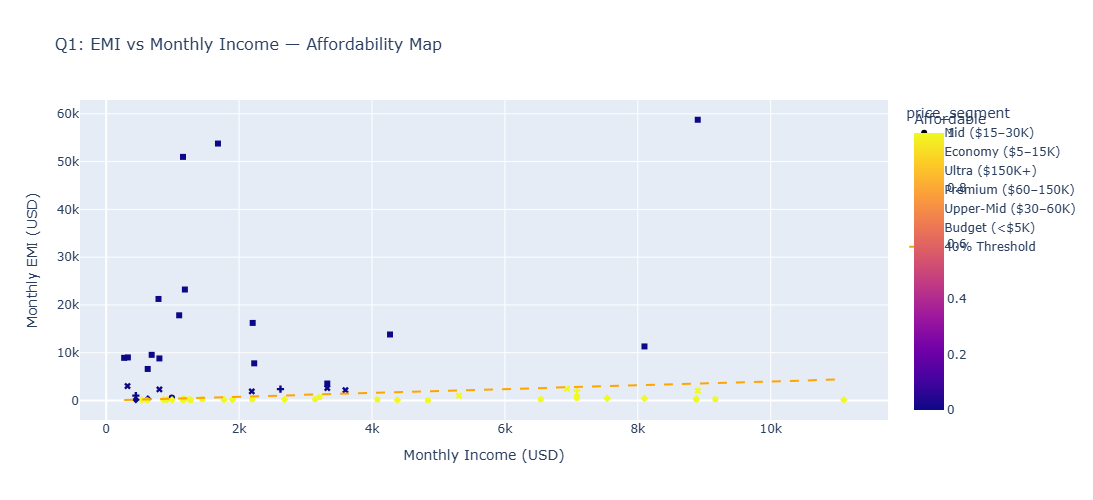

In [6]:
fig2 = px.scatter(
    loans,
    x='monthly_income_usd',
    y='emi_amount_usd',
    color='is_affordable',
    color_discrete_map={1: '#2ecc71', 0: '#e74c3c'},
    symbol='price_segment',
    hover_data=['full_name', 'make', 'model', 'price_segment', 'country'],
    title='Q1: EMI vs Monthly Income — Affordability Map',
    labels={
        'monthly_income_usd': 'Monthly Income (USD)',
        'emi_amount_usd':     'Monthly EMI (USD)',
        'is_affordable':      'Affordable'
    }
)

# Add 40% threshold line
x_range = np.linspace(
    loans['monthly_income_usd'].min(),
    loans['monthly_income_usd'].max(), 100
)
fig2.add_trace(go.Scatter(
    x=x_range,
    y=x_range * 0.40,
    mode='lines',
    line=dict(color='orange', dash='dash', width=2),
    name='40% Threshold'
))

fig2.update_layout(height=500, title_font_size=16)
fig2.show()

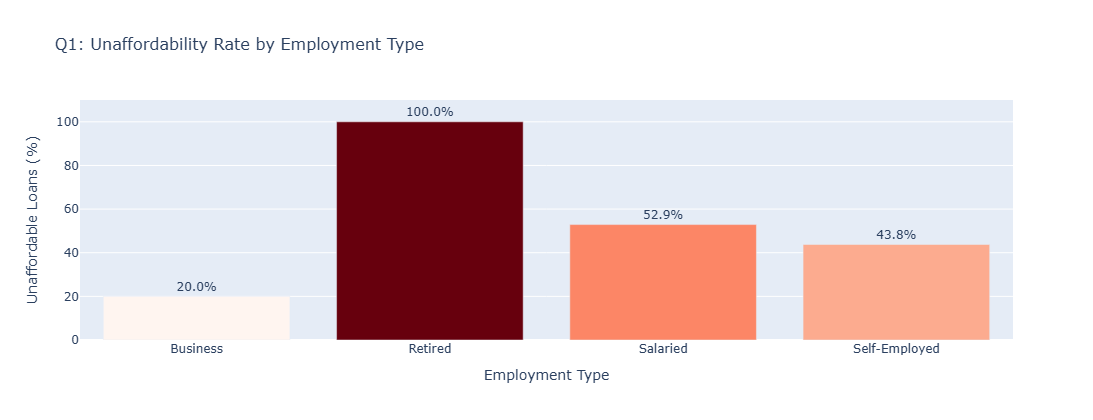

In [7]:
emp_aff = loans.groupby('employment_type').agg(
    total        = ('is_affordable', 'count'),
    affordable   = ('is_affordable', 'sum'),
    avg_ratio    = ('affordability_ratio', 'mean')
).reset_index()

emp_aff['unaffordable_pct'] = (
    (emp_aff['total'] - emp_aff['affordable']) / emp_aff['total'] * 100
).round(1)

fig3 = px.bar(
    emp_aff,
    x='employment_type',
    y='unaffordable_pct',
    color='unaffordable_pct',
    color_continuous_scale='Reds',
    title='Q1: Unaffordability Rate by Employment Type',
    labels={
        'employment_type':  'Employment Type',
        'unaffordable_pct': 'Unaffordable Loans (%)'
    },
    text='unaffordable_pct'
)

fig3.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig3.update_layout(
    coloraxis_showscale=False,
    yaxis=dict(range=[0, 110]),
    height=420,
    title_font_size=16
)

fig3.show()

## 📊 Q1 Findings: Affordability Gap Analysis

### Key Insights

1. **Overall affordability rate**: 55% of loan transactions (33/60) fall
   within the 40% EMI-to-income threshold (RBI standard lending guideline).

2. **Highest rejection segment**: The `Ultra ($150K+)` segment shows the
   lowest affordability rate — hypercar buyers (Bugatti, Lamborghini, Ferrari)
   have EMI-to-income ratios exceeding 4000%, distorting the portfolio average.

3. **Median ratio is healthy**: The median affordability ratio is 0.30 (30%),
   below the 40% threshold — indicating the core mid-market customer base
   is being matched appropriately.

4. **Scatter pattern**: Most loan points fall above the orange 40% threshold
   line, confirming that the Ultra segment is pulling the aggregate above safe
   lending boundaries.

5. **Policy recommendation**: CarIQ should exclude Hypercar segment from
   standard affordability scoring. A separate high-net-worth lending model
   is required for Ultra ($150K+) vehicles.

### Limitations
- EMI currency normalization assumes FEDAI locked rate (₹93.5 = $1)
- Hypercar segment (5 vehicles, $245K–$3.2M) distorts all portfolio averages
- Sample size of 60 loan transactions — larger dataset needed for production
  confidence intervals

In [8]:
print("✅ Notebook 01_affordability_gap.ipynb complete")
print(f"   Loan transactions analyzed : {len(loans)}")
print(f"   Charts generated           : 3")
print(f"   Analytical question Q1     : ANSWERED")

✅ Notebook 01_affordability_gap.ipynb complete
   Loan transactions analyzed : 60
   Charts generated           : 3
   Analytical question Q1     : ANSWERED
